In [20]:
#Si queremos que las imágenes sean mostradas en una ventana emergente quitar el inline
%matplotlib inline  
#%matplotlib qt
# OpenCV-Python utiliza NumPy para el manejo de imágenes
import numpy as np # type: ignore
# cv2 es el módulo python para acceder a OpenCV 
import cv2 as cv
# Usamos las poderosas herramientas de graficación de matplotlib para mostrar imágenes, perfiles, histogramas, etc
import matplotlib.pyplot as plt
import os

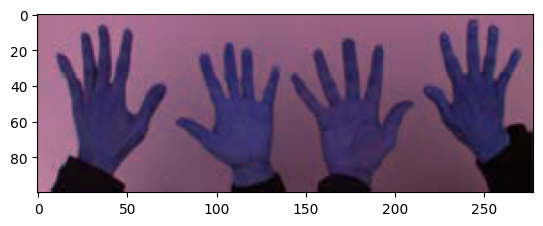

In [4]:
# Cargar una imagen en modo monocromático (un canal)
img_color = cv.imread('Material_TPs/TP1/white_patch/test_blue.png')
plt.imshow(img_color)
plt.show()

In [24]:
def white_patch(img):
    # Convertir imagen a float32 para evitar saturación
    img_float = img.astype(np.float32)

    # Separar los canales
    max_vals = np.max(img_float, axis=(0, 1))  # máximo por canal
    scale = 255.0 / max_vals
    print(max_vals,scale)

    # Escalar cada canal por su máximo
    balanced = img_float * scale

    # Clipping para evitar valores mayores a 255
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)
    
    # Mostrar resultados
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(balanced)
    plt.title("White Patch")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return balanced



[255. 134. 122.] [1.        1.9029851 2.090164 ]


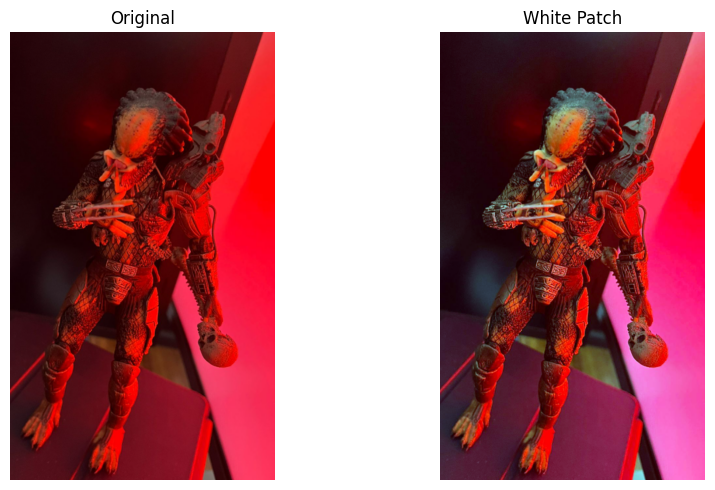

[210. 250. 171.] [1.2142857 1.02      1.4912281]


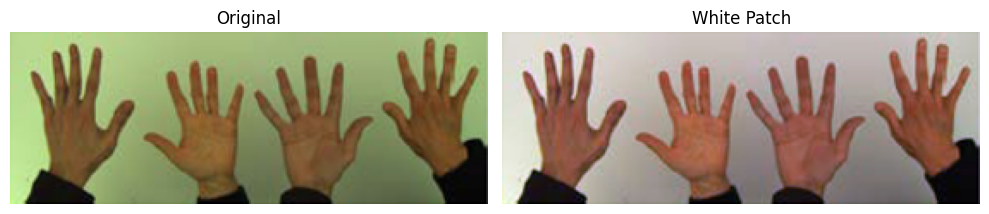

[126. 252. 155.] [2.0238094 1.0119047 1.6451613]


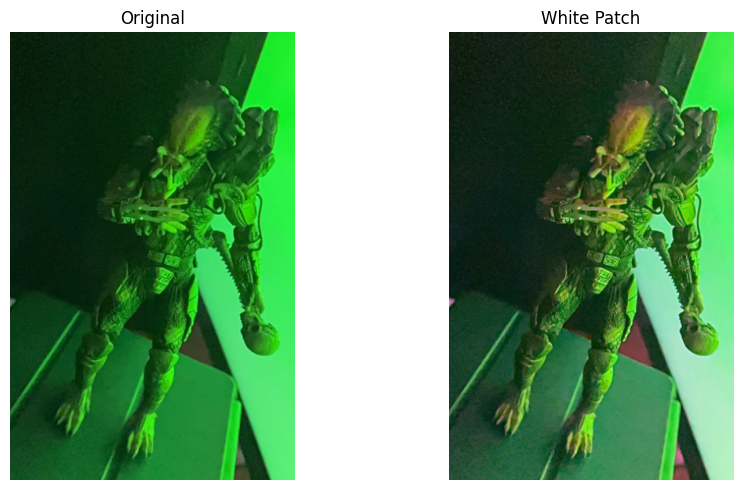

[255. 201. 203.] [1.        1.2686567 1.2561576]


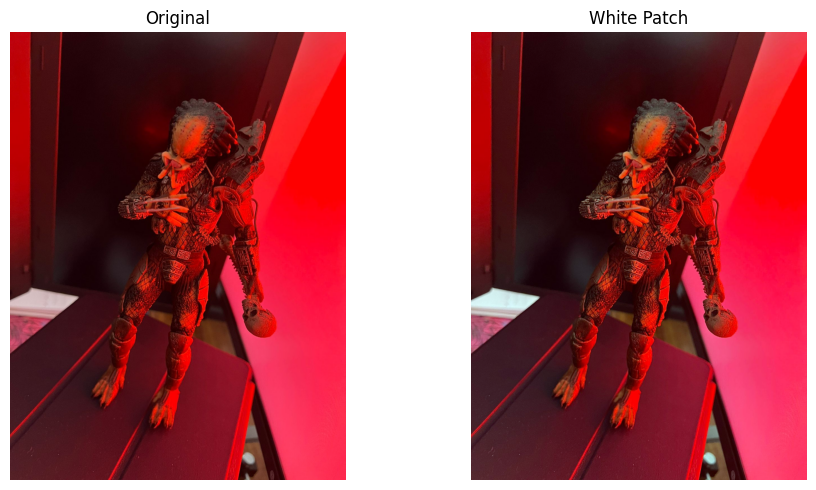

[247. 157. 175.] [1.0323887 1.6242038 1.4571428]


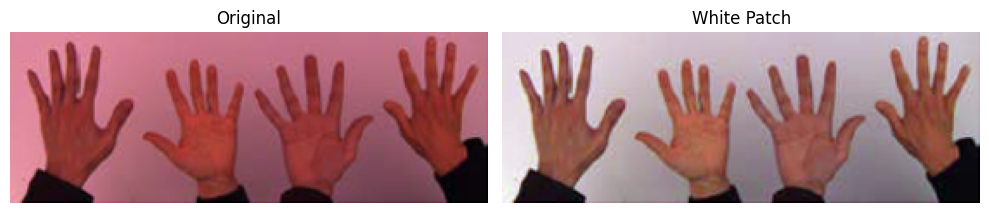

[170. 255. 172.] [1.5       1.        1.4825581]


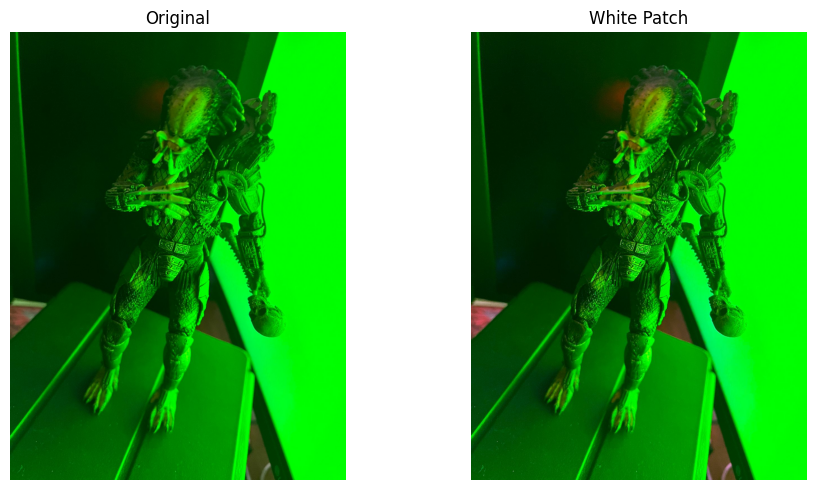

[255. 255. 255.] [1. 1. 1.]


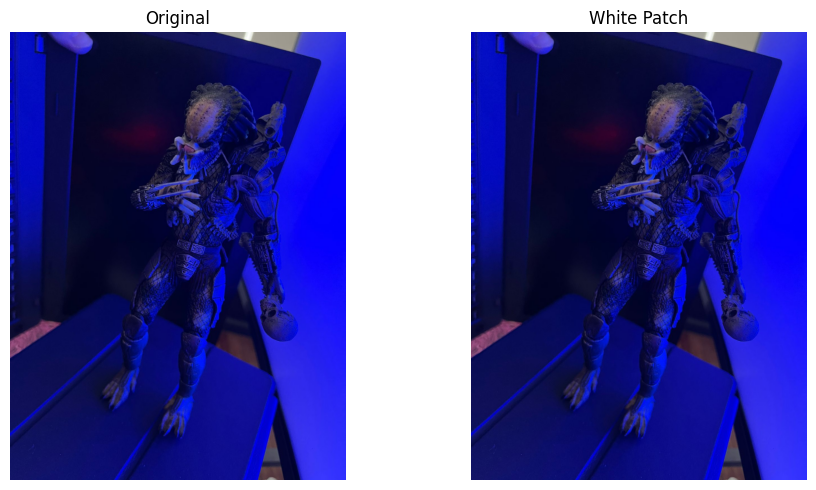

[165. 138. 200.] [1.5454545 1.8478261 1.275    ]


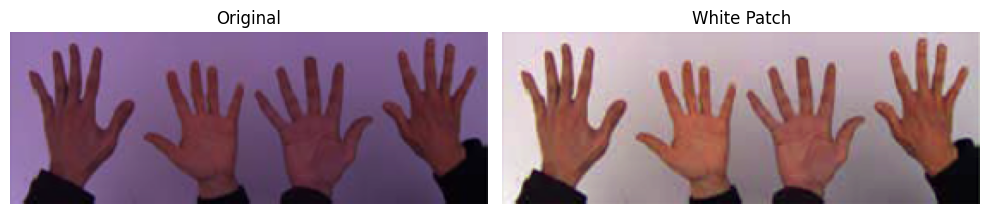

In [25]:
carpeta='Material_TPs/TP1/white_patch/'
for nombre_archivo in os.listdir(carpeta):
        ruta_completa = os.path.join(carpeta, nombre_archivo)

        # Leer imagen en BGR y convertir a RGB
        img_bgr = cv.imread(ruta_completa)
        img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

        # Aplicar White Patch
        img_wp = white_patch(img_rgb)

Notamos en los casos de wp_blue y wp_green2 que el algoritmo no genera un impacto significativo en el contraste y el cambio de escala de los pixeles de la imagen. Esto se debe a que los valores de los pixeles en los tres canales tienden a valores cercanos a 255 y cercanos entre ellos, lo cual genera un valor de normalización cercano a 1 y genera como resultado una imagen de iluminación muy similar.

[[  2   3   4 ...  13  13  14]
 [ 14  14  14 ...  20  20  20]
 [ 20  20  20 ...  22  22  22]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


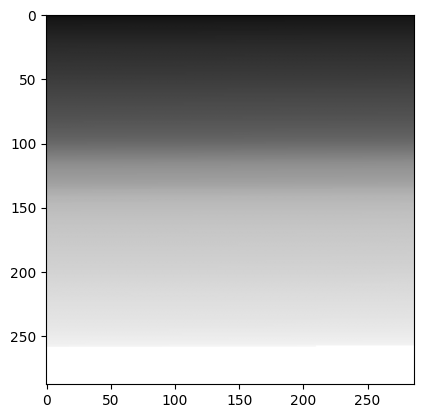

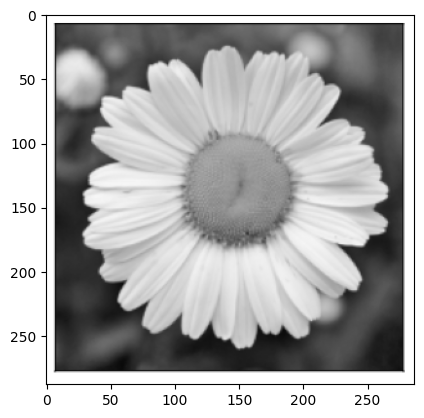

In [34]:
# Cargar una imagen en modo monocromático (un canal)
img_tp_1 = cv.imread('Material_TPs/TP1/img1_tp.png', cv.IMREAD_GRAYSCALE)
img_tp_2 = cv.imread('Material_TPs/TP1/img2_tp.png', cv.IMREAD_GRAYSCALE)

# Dimensión de la imagen
print(img_tp_1)
print(img_tp_2)

plt.figure()
plt.imshow(img_tp_1,cmap='gray')
plt.show()

plt.figure()
plt.imshow(img_tp_2,cmap='gray')
plt.show()

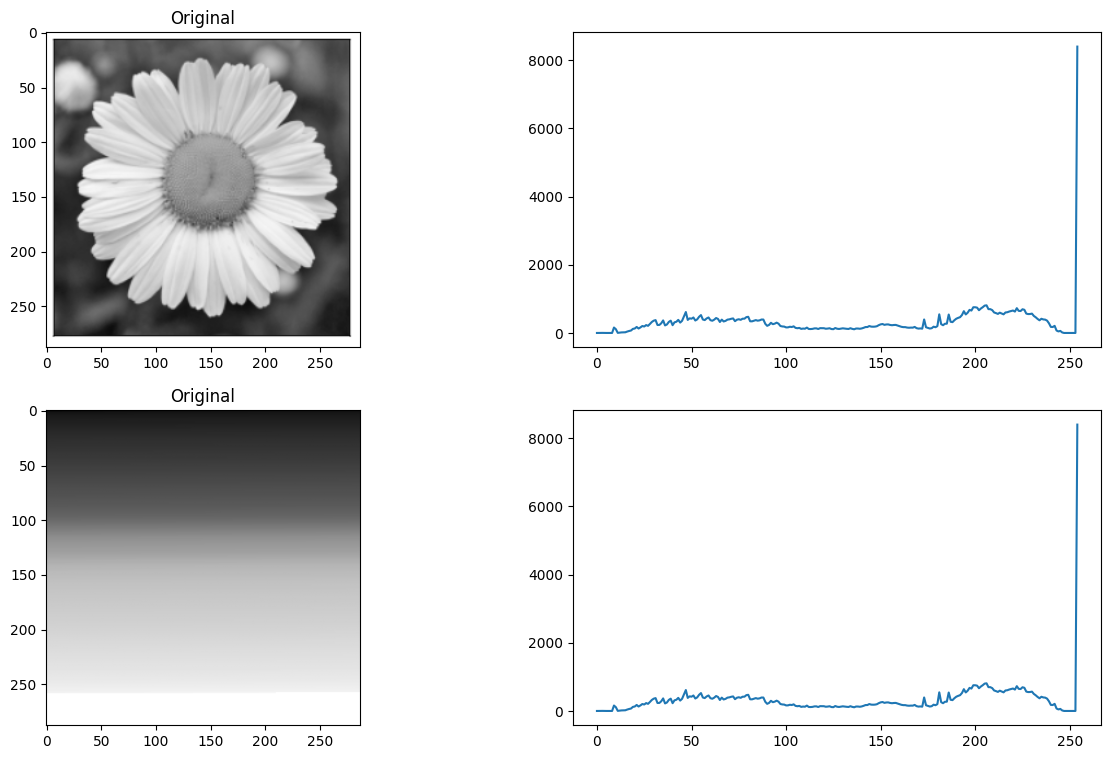

In [51]:
# Nueva figura
fig = plt.figure(figsize=(15, 9))

# Imagen original
ax1=plt.subplot(221)
ax1.imshow(img_tp_2, cmap='gray', vmin=0, vmax=255)
ax1.set_title('Original')

hist1,bins1 = np.histogram(img_tp_2.ravel(),255,[0,256])
ax3=plt.subplot(222)
ax3.plot(hist1)

# Imagen original
ax2=plt.subplot(223)
ax2.imshow(img_tp_1, cmap='gray', vmin=0, vmax=255)
ax2.set_title('Original')

hist2,bins2 = np.histogram(img_tp_1.ravel(),255,[0,256])
ax4=plt.subplot(224)
ax4.plot(hist2)

plt.show()

Se observa que por la similitud de distribución de píxeles en los histogramas de ambas imagenes, que los mismos reflejan comportamientos muy similares. Por lo cual, si utilizaramos esta variable como un feature de clasificación, probablemente generaría muchos errores y sería muy impreciso ya que no es un dato que me logre diferenciar de manera clara una imagen de otra.